In [6]:
import agrodesign
print(agrodesign)


<module 'agrodesign' from 'D:\\Git Projects\\AGRODESIGN\\agrodesign\\__init__.py'>


In [7]:
from agrodesign.analysis.anova import Anova
from agrodesign.mean_separation.lsd import LSD

In [8]:
import pandas as pd

df = pd.DataFrame({
    "Treatment": ["T1","T1","T2","T2","T3","T3"],
    "Yield": [10,12,15,14,18,17]
})

aov = Anova(df, response="Yield")
aov.crd(treatment="Treatment")


,DF,SS,MS,F,p-value
C(Treatment),2.0,42.333333,21.166667,21.166667,0.017024
Residual,3.0,3.000000,1.000000,NaN,NaN


In [10]:
aov.crd("Treatment")
aov.means("Treatment")
from agrodesign.mean_separation.dmrt import DMRT
DMRT(aov).test()

,Treatment,Mean,Replications,Group
0,T3,17.5,2,a
1,T2,14.5,2,a
2,T1,11.0,2,b


In [6]:
aov.means(treatment="Treatment")
lsd = LSD(aov)
lsd.test()

,Treatment,Mean,Replications,Group
0,T3,17.5,2,a
1,T2,14.5,2,a
2,T1,11.0,2,b


In [2]:
import pandas as pd
from agrodesign.analysis.anova import Anova
from agrodesign.mean_separation.lsd import LSD

df = pd.DataFrame({
    "Block": ["B1","B1","B1","B2","B2","B2"],
    "Treatment": ["T1","T2","T3","T1","T2","T3"],
    "Yield": [10,14,18,12,15,17]
})

aov = Anova(df, response="Yield")

# RCBD ANOVA
aov.rcbd(treatment="Treatment", block="Block")


,DF,SS,MS,F,p-value
C(Treatment),2.0,42.333333,21.166667,18.142857,0.052239
C(Block),1.0,0.666667,0.666667,0.571429,0.528595
Residual,2.0,2.333333,1.166667,NaN,NaN


In [3]:
# Treatment means
aov.means("Treatment")


,Treatment,Mean,Replications
0,T1,11.0,2
1,T2,14.5,2
2,T3,17.5,2


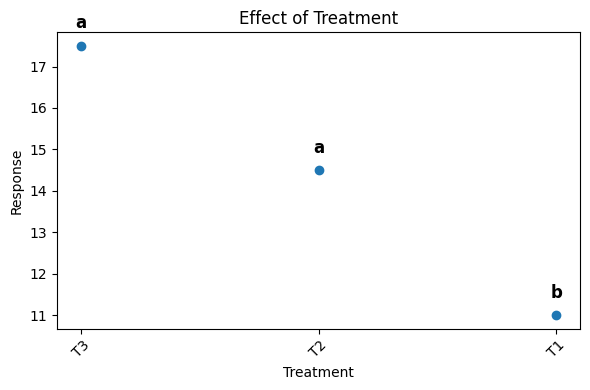

,Treatment,Mean,Replications,Group
0,T3,17.5,2,a
1,T2,14.5,2,a
2,T1,11.0,2,b


In [5]:
from agrodesign.plots.effect_plot import effect_plot
effect_plot(aov, "Treatment", method="dmrt")


In [9]:
# LSD test
lsd = LSD(aov)
lsd.test()


,Treatment,Mean,Replications,Group
0,T3,17.5,2,a
1,T2,14.5,2,a
2,T1,11.0,2,a


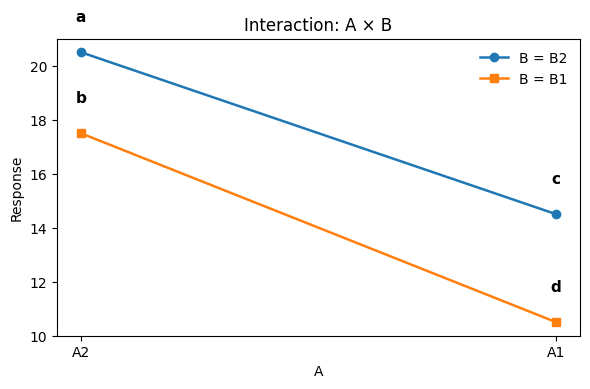

<Axes: title={'center': 'Interaction: A × B'}, xlabel='A', ylabel='Response'>

In [1]:
import pandas as pd
from agrodesign.analysis.anova import Anova
from agrodesign.plots.interaction_plot import interaction_plot

df = pd.DataFrame({
    "A": ["A1","A1","A1","A1","A2","A2","A2","A2"],
    "B": ["B1","B1","B2","B2","B1","B1","B2","B2"],
    "Yield": [10,11,14,15,18,17,20,21]
})

aov = Anova(df, response="Yield")

# factorial ANOVA
aov.factorial(["A","B"])
aov.factorial_means(["A","B"])

# interaction plot with letters
interaction_plot(aov, ["A","B"], method="dmrt")


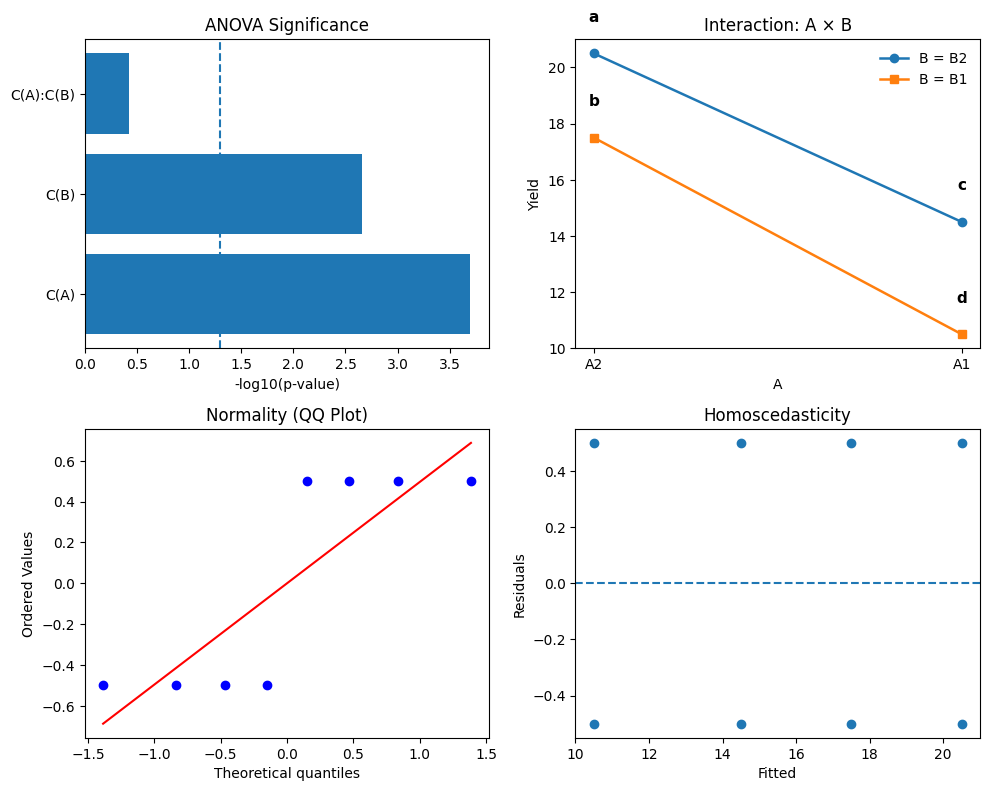

In [2]:
from agrodesign.plots.report_plot import report_plot
report_plot(aov, ["A","B"])


In [6]:
aov.factorial_means("A")

from agrodesign.mean_separation.lsd import LSD
lsd_A = LSD(aov)
lsd_A.test()


,A,Mean,Replications,Group
0,A2,19.0,4,a
1,A1,12.5,4,b


In [4]:
from agrodesign.analysis.assumptions import Assumptions

assump = Assumptions(aov)

# Normality
assump.shapiro_test()


{'Test': 'Shapiro-Wilk',
 'Statistic': np.float64(0.6646559035934576),
 'p-value': np.float64(0.0008917018985140214),
 'Normal': 'No'}

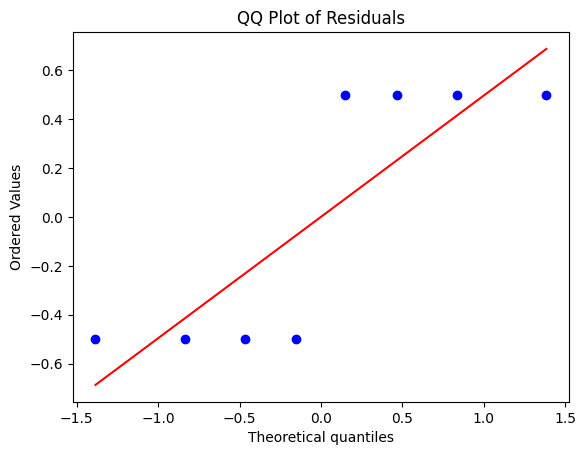

In [4]:
assump.qq_plot()


In [6]:
assump.bartlett_test("A")

{'Test': 'Bartlett',
 'Statistic': np.float64(0.8781123262779806),
 'p-value': np.float64(0.3487192197203338),
 'Homogeneous': 'Yes'}

In [12]:
df

,A,B,Yield
0,A1,B1,10
1,A1,B1,11
2,A1,B2,14
3,A1,B2,15
4,A2,B1,18
5,A2,B1,17
6,A2,B2,20
7,A2,B2,21


In [7]:
from agrodesign.mean_separation.tukey import TukeyHSD

tukey = TukeyHSD(aov, factor="A")
tukey.test()


,A,Mean,Group
0,A2,19.0,a
1,A1,12.5,b


In [8]:
from agrodesign.mean_separation.tukey import TukeyHSD

tukey_A = TukeyHSD(aov, factor=("A","B"))
tukey_A.test()


,A:B,Mean,Group
0,A2:B2,20.5,a
1,A2:B1,17.5,b
2,A1:B2,14.5,c
3,A1:B1,10.5,d


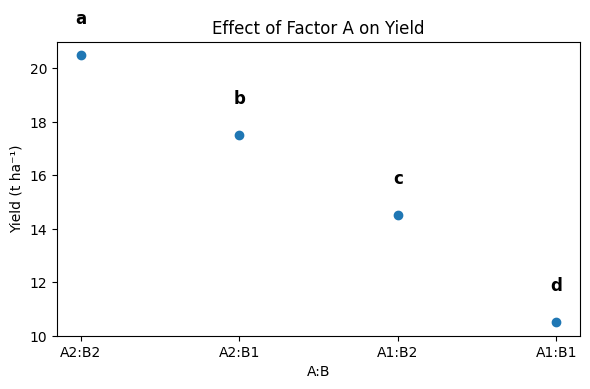

In [9]:
from agrodesign.mean_separation.tukey import TukeyHSD

tukey_A = TukeyHSD(aov, factor=("A","B"))
means_A = tukey_A.test()

mean_plot(
    means_df=means_A,
    factor="A:B",
    ylabel="Yield (t ha⁻¹)",
    title="Effect of Factor A on Yield",
    kind="point"
)


In [2]:
import pandas as pd
from agrodesign.analysis.anova import Anova
from agrodesign.mean_separation.lsd import LSD

In [4]:
import pandas as pd
from agrodesign.analysis.anova import Anova
from agrodesign.mean_separation.lsd import LSD
from agrodesign.mean_separation.tukey import TukeyHSD
df = pd.DataFrame({
    "Rep": [1]*8 + [2]*8 + [3]*8,
    "A": ["A1","A1","A1","A1","A2","A2","A2","A2"] * 3,
    "B": ["B1","B1","B2","B2","B1","B1","B2","B2"] * 3,
    "C": ["C1","C2","C1","C2","C1","C2","C1","C2"] * 3,
    "Yield": [
        10,12,11,13,15,17,16,18,
        11,13,12,14,16,18,17,19,
        12,14,13,15,17,19,18,20
    ]
})



In [5]:
aov = Anova(df, response="Yield")
anova_table = aov.split_plot(
    whole_plot="A",
    sub_plot="B",
    block="Rep",
    sub_sub_plot="C"
)

anova_table


,DF,SS,MS,F,p-value
C(Rep),2.0,1.600000e+01,8.000000e+00,3.597448e+27,1.528488e-108
C(A),1.0,1.500000e+02,1.500000e+02,1.188422e+31,0.000000e+00
C(B),1.0,6.000000e+00,6.000000e+00,1.301042e+30,0.000000e+00
C(C),1.0,2.400000e+01,2.400000e+01,1.079234e+28,8.255723e-110
C(Rep):C(A),2.0,2.524355e-29,1.262177e-29,5.675772e-03,9.943443e-01
C(A):C(B),1.0,2.174298e-29,2.174298e-29,4.714756e+00,9.566562e-02
C(A):C(C),1.0,1.972152e-29,1.972152e-29,8.868393e-03,9.272883e-01
C(B):C(C),1.0,3.081488e-33,3.081488e-33,1.385686e-06,9.990896e-01
C(Rep):C(A):C(B),4.0,1.844675e-29,4.611687e-30,2.073788e-03,9.999893e-01
C(A):C(B):C(C),1.0,4.039908e-29,4.039908e-29,1.816670e-02,8.961122e-01


In [6]:
aov.factorial_means(["A", "B", "C"])


,A,B,C,Mean,Replications
0,A1,B1,C1,11.0,3
1,A1,B1,C2,13.0,3
2,A1,B2,C1,12.0,3
3,A1,B2,C2,14.0,3
4,A2,B1,C1,16.0,3
5,A2,B1,C2,18.0,3
6,A2,B2,C1,17.0,3
7,A2,B2,C2,19.0,3


In [ ]:
lsd_ABC = LSD(aov, effect="A:B:C")
lsd_ABC.test()

,A,B,C,Mean,Replications,Group
0,A2,B2,C2,19.0,3,a
1,A2,B1,C2,18.0,3,b
2,A2,B2,C1,17.0,3,c
3,A2,B1,C1,16.0,3,d
4,A1,B2,C2,14.0,3,e
5,A1,B1,C2,13.0,3,f
6,A1,B2,C1,12.0,3,g
7,A1,B1,C1,11.0,3,h


In [9]:
aov.factorial_means("A")

lsd_A = LSD(aov, effect="A")
lsd_A.test()

,A,Mean,Replications,Group
0,A2,17.5,12,a
1,A1,12.5,12,b


In [10]:
tukey_B = TukeyHSD(aov, effect="B")
tukey_B.test()


,A,Mean,Replications,Group
0,A2,17.5,12,a
1,A1,12.5,12,b


In [12]:
aov.factorial_means(["A","C"])
LSD(aov, effect="A:C").test()

aov.factorial_means(["B","C"])
TukeyHSD(aov, effect="B:C").test()


,B,C,Mean,Replications,Group
0,B2,C2,16.5,6,a
1,B1,C2,15.5,6,b
2,B2,C1,14.5,6,c
3,B1,C1,13.5,6,d


In [1]:
import pandas as pd
from agrodesign.analysis.anova import Anova
from agrodesign.plots.boxplot_letters import boxplot_letters


In [ ]:
import pandas as pd
df = pd.DataFrame({
    "Rep": [1]*8 + [2]*8 + [3]*8,
    "A": ["A1","A1","A1","A1","A2","A2","A2","A2"] * 3,
    "B": ["B1","B1","B2","B2","B1","B1","B2","B2"] * 3,
    "C": ["C1","C2","C1","C2","C1","C2","C1","C2"] * 3,
    "Yield": [
        10,12,11,13,15,17,16,18,
        11,13,12,14,16,18,17,19,
        12,14,13,15,17,19,18,20
    ]
})

In [2]:
from agrodesign.experiment import Experiment

Experiment(df,"Yield").factorial(["A","B","C"]).run()



================ AGRODESIGN ANALYSIS ================

FACTORIAL EXPERIMENT ANALYSIS
Response variable: Yield

ANOVA TABLE
                  DF            SS            MS             F       p-value
C(A)             1.0  1.500000e+02  1.500000e+02  1.500000e+02  1.529894e-09
C(B)             1.0  6.000000e+00  6.000000e+00  6.000000e+00  2.619949e-02
C(C)             1.0  2.400000e+01  2.400000e+01  2.400000e+01  1.605342e-04
C(A):C(B)        1.0  1.953435e-28  1.953435e-28  1.953435e-28  1.000000e+00
C(A):C(C)        1.0  1.449532e-29  1.449532e-29  1.449532e-29  1.000000e+00
C(B):C(C)        1.0  8.549280e-29  8.549280e-29  8.549280e-29  1.000000e+00
C(A):C(B):C(C)   1.0  2.662406e-30  2.662406e-30  2.662406e-30  1.000000e+00
Residual        16.0  1.600000e+01  1.000000e+00           NaN           NaN


UnboundLocalError: cannot access local variable 'sep' where it is not associated with a value

In [3]:
import pandas as pd
from agrodesign.experiment import Experiment

df = pd.DataFrame({
    "Treatment": ["T1","T2","T3","T4"] * 5,
    "Yield": [
        42,50,55,60,
        41,48,53,59,
        43,49,56,61,
        40,47,54,58,
        44,51,57,62
    ]
})



================ AGRODESIGN ANALYSIS ================

COMPLETELY RANDOMIZED DESIGN ANALYSIS
Response variable: Yield

ANOVA TABLE
                DF     SS          MS           F       p-value
C(Treatment)   3.0  905.0  301.666667  120.666667  3.374770e-11
Residual      16.0   40.0    2.500000         NaN           NaN

========== MEAN COMPARISON ==========

Effect: Treatment
HSD(0.05) = 2.8612
  Treatment  Mean  Replications Group
0        T4  60.0             5     a
1        T3  55.0             5     b
2        T2  49.0             5     c
3        T1  42.0             5     d


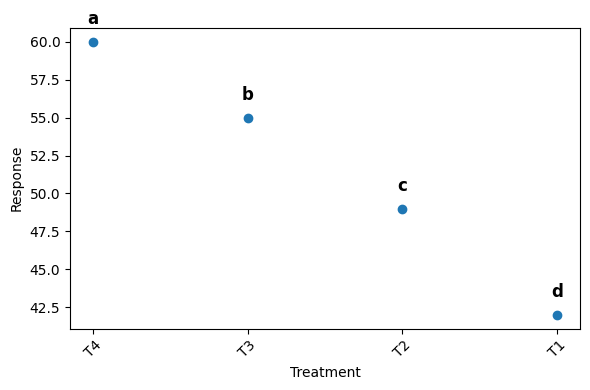


========== ASSUMPTIONS ==========
Shapiro p-value: {'Test': 'Shapiro-Wilk', 'Statistic': np.float64(0.895883512369101), 'p-value': np.float64(0.034548326289017196), 'Normal': 'No'}

========== FINAL RECOMMENDATION ==========
CRD INTERPRETATION

Significant effects detected in: C(Treatment).
For Treatment, 'T4' produced the highest yield (60.000) and belongs to the superior group 'a'.

FINAL RECOMMENDATION:
Adopt treatment combination T4 for maximizing 60.000 yield under this experiment.


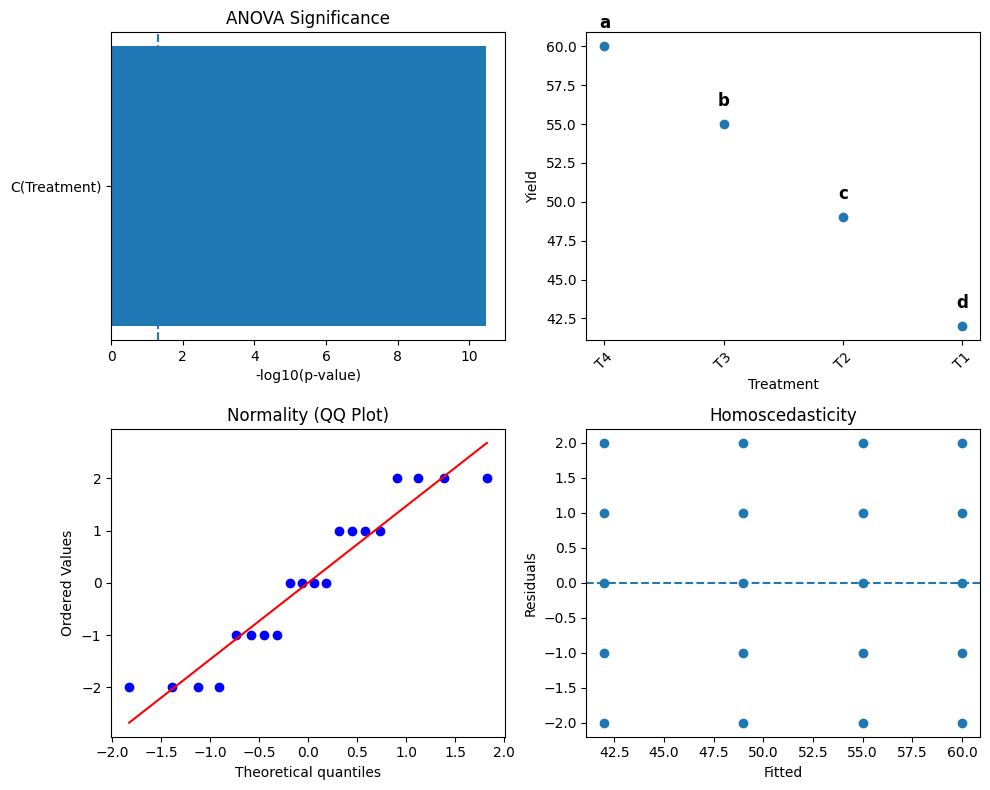

In [5]:
Experiment(df,"Yield").crd("Treatment").run()



================ AGRODESIGN ANALYSIS ================

RANDOMIZED COMPLETE BLOCK DESIGN ANALYSIS
Response variable: Yield

ANOVA TABLE
             DF            SS            MS             F       p-value
C(Variety)  3.0  3.750000e+02  1.250000e+02  2.971056e+29  6.672760e-88
C(Block)    2.0  8.000000e+00  4.000000e+00  9.507380e+27  3.141820e-83
Residual    6.0  2.524355e-27  4.207258e-28           NaN           NaN

========== MEAN COMPARISON ==========

Effect: Variety
HSD(0.05) = 0.0000
  Variety  Mean  Replications Group
0      V4  60.0             3     a
1      V3  55.0             3     b
2      V2  50.0             3     c
3      V1  45.0             3     d


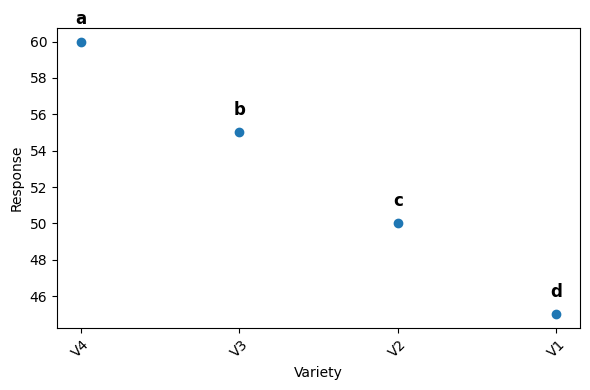


========== ASSUMPTIONS ==========
Shapiro p-value: {'Test': 'Shapiro-Wilk', 'Statistic': np.float64(0.8853571193858183), 'p-value': np.float64(0.10268378615256352), 'Normal': 'Yes'}

========== FINAL RECOMMENDATION ==========
RCBD INTERPRETATION

Significant effects detected in: C(Variety), C(Block).
For Variety, 'V4' produced the highest yield (60.000) and belongs to the superior group 'a'.

FINAL RECOMMENDATION:
Adopt treatment combination V4 for maximizing 60.000 yield under this experiment.


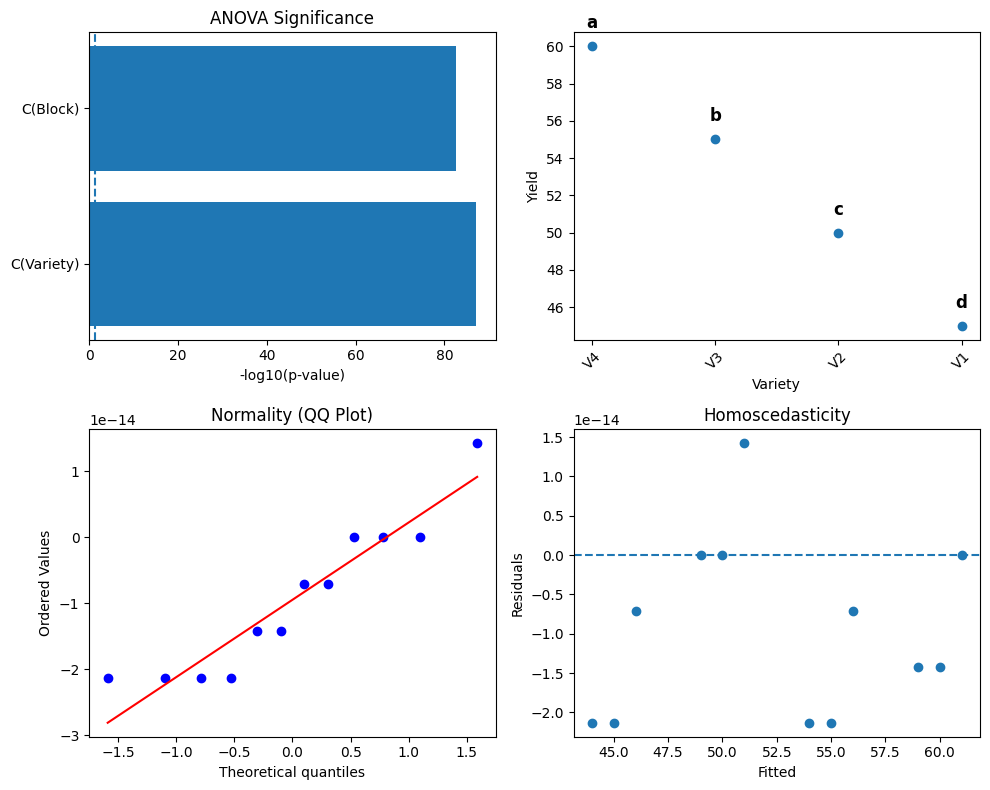

In [6]:
df = pd.DataFrame({
    "Block": [1,1,1,1,2,2,2,2,3,3,3,3],
    "Variety": ["V1","V2","V3","V4"]*3,
    "Yield": [
        45,50,55,60,
        44,49,54,59,
        46,51,56,61
    ]
})
Experiment(df,"Yield").rcbd("Variety","Block").run()



================ AGRODESIGN ANALYSIS ================

SPLIT-PLOT EXPERIMENT ANALYSIS
Response variable: Yield

ANOVA TABLE
                            DF            SS            MS             F  \
C(Rep)                     2.0  1.600000e+01  8.000000e+00  2.133333e+01   
C(Irrigation)              1.0  1.500000e+02  1.500000e+02  2.376845e+31   
C(Variety)                 1.0  2.400000e+01  2.400000e+01  6.400000e+01   
C(Rep):C(Irrigation)       2.0  1.262177e-29  6.310887e-30  1.682903e-29   
C(Irrigation):C(Variety)   1.0  2.839899e-29  2.839899e-29  7.573065e-29   
Residual                  16.0  6.000000e+00  3.750000e-01           NaN   

                               p-value  
C(Rep)                    3.060755e-05  
C(Irrigation)             0.000000e+00  
C(Variety)                5.545448e-07  
C(Rep):C(Irrigation)      1.000000e+00  
C(Irrigation):C(Variety)  1.000000e+00  
Residual                           NaN  

========== MEAN COMPARISON ==========

Effect: Irrigat

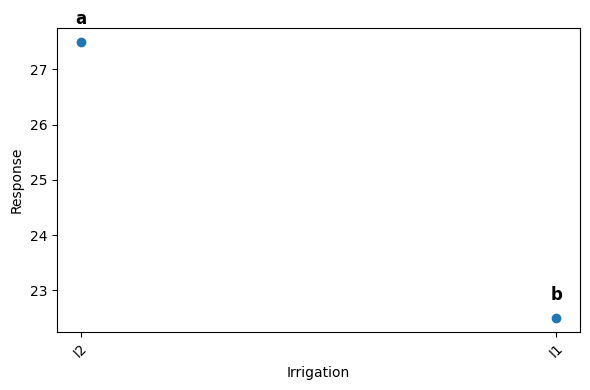


Effect: Variety
HSD(0.05) = 0.5300
  Variety  Mean  Replications Group
0      V2  26.0            12     a
1      V1  24.0            12     b


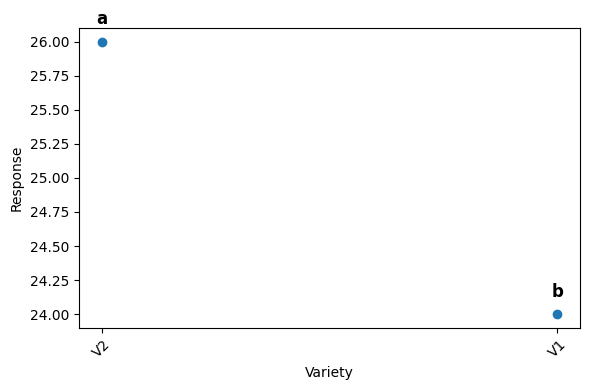


Effect: Irrigation × Variety
HSD(0.05) = 1.0116
  Irrigation Variety  Mean  Replications Group
0         I2      V2  28.5             6     a
1         I2      V1  26.5             6     b
2         I1      V2  23.5             6     c
3         I1      V1  21.5             6     d


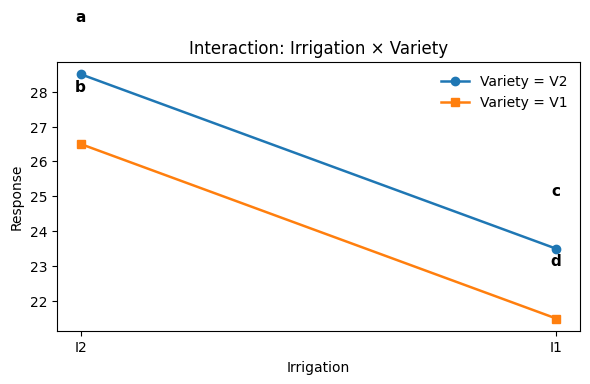


========== ASSUMPTIONS ==========
Shapiro p-value: {'Test': 'Shapiro-Wilk', 'Statistic': np.float64(0.6395375876169219), 'p-value': np.float64(1.7619188418204254e-06), 'Normal': 'No'}

========== FINAL RECOMMENDATION ==========
SPLIT INTERPRETATION

Significant effects detected in: C(_F0), C(_F1), C(_F2).
For Irrigation, 'I2' produced the highest yield (27.500) and belongs to the superior group 'a'.
For Variety, 'V2' produced the highest yield (26.000) and belongs to the superior group 'a'.
For Irrigation × Variety, 'I2 × V2' produced the highest yield (28.500) and belongs to the superior group 'a'.

FINAL RECOMMENDATION:
Adopt treatment combination I2 × V2 for maximizing 28.500 yield under this experiment.


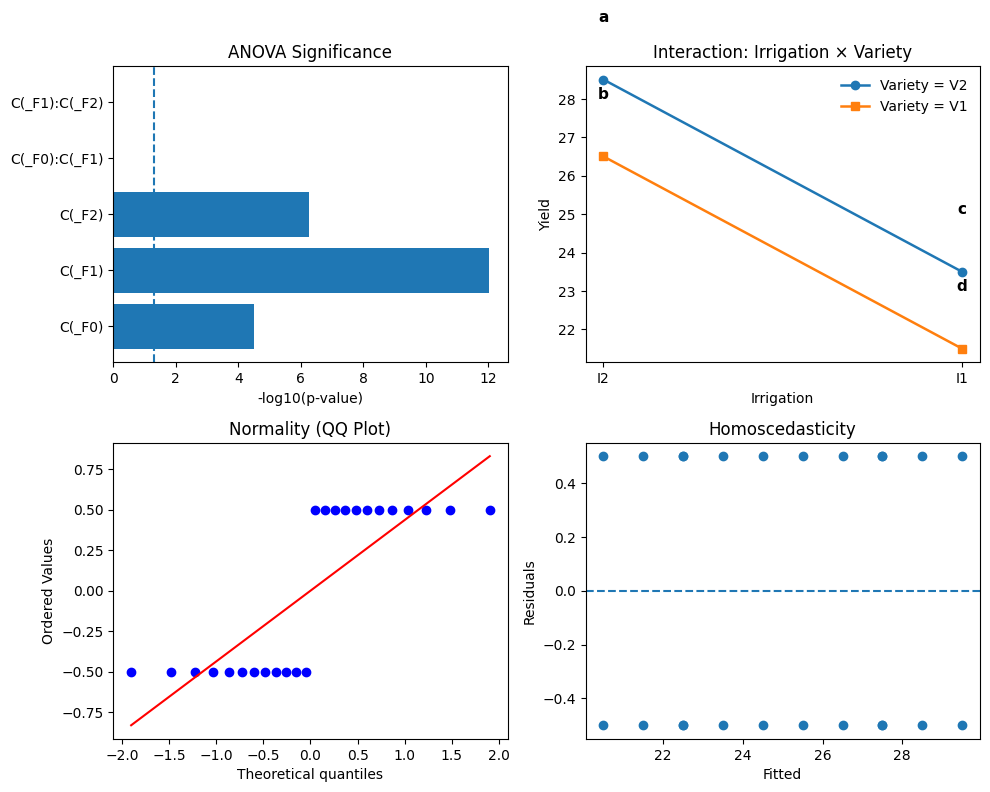

In [7]:
df = pd.DataFrame({
    "Rep":[1]*8+[2]*8+[3]*8,
    "Irrigation":["I1","I1","I1","I1","I2","I2","I2","I2"]*3,
    "Variety":["V1","V2","V1","V2","V1","V2","V1","V2"]*3,
    "Yield":[
        20,22,21,23,25,27,26,28,
        21,23,22,24,26,28,27,29,
        22,24,23,25,27,29,28,30
    ]
})

Experiment(df,"Yield").split_plot("Irrigation","Variety","Rep").run()


In [1]:
import pandas as pd
from agrodesign.experiment import Experiment

df = pd.DataFrame({
    "Block":[1,1,1,2,2,2,3,3,3],
    "Treatment":["T1","T2","T3"]*3,
    "Yield":[42,50,55,40,48,54,43,49,56]
})
Experiment(df,"Yield").mixed(fixed=["Treatment"], random=["Block"]).run()


================ AGRODESIGN ANALYSIS ================

MIXED MODEL ANALYSIS

Variance Components
     Effect            Type  Variance   Std.Dev
0     Block  Random (Group)  0.999989  0.999995
1  Residual           Error  0.444446  0.666668

BLUPs
   Block      BLUP
0      3  0.677418
1      1  0.387096
2      2 -1.064514

INTERPRETATION
MIXED MODEL INTERPRETATION

Random effect variance exceeds residual variance indicating strong environmental heterogeneity.
The experiment showed moderate precision.
Level '3.0' had the highest predicted performance (BLUP = 0.677).
Level '2.0' showed the lowest performance (BLUP = -1.065).


In [2]:
df = pd.DataFrame({
    "Genotype":["G1","G2","G3","G4"]*8,
    "Environment":(["E1"]*4 + ["E2"]*4 + ["E3"]*4 + ["E4"]*4)*2,
    "Rep":[1]*16 + [2]*16,
    "Yield":[
        45,50,55,60,
        40,48,53,58,
        47,52,57,62,
        43,49,54,59,

        46,51,56,61,
        41,47,52,57,
        48,53,58,63,
        44,50,55,60
    ]
})
Experiment(df,"Yield").gxe("Genotype","Environment","Rep").run()



================ AGRODESIGN ANALYSIS ================

G×E ANALYSIS

ANOVA
                              sum_sq    df           F        PR(>F)
C(Genotype)                 1093.375   3.0  728.916667  2.578571e-17
C(Environment)               127.375   3.0   84.916667  4.833265e-10
C(Genotype):C(Environment)     4.125   9.0    0.916667  5.352313e-01
Residual                       8.000  16.0         NaN           NaN

Variance Components
  Variance Component      Value
0           Genotype  45.495308
1           Residual   0.485002

Heritability: 0.9946980216971271

Genotype BLUPs
  Genotype      BLUP
0       G4  7.677270
1       G3  2.683924
2       G2 -2.309423
3       G1 -8.051771

INTERPRETATION
GENOTYPE × ENVIRONMENT INTERPRETATION

Significant genotypic differences detected indicating genetic variability.
Environments differed significantly indicating strong environmental influence.
Non-significant G×E interaction indicating stable genotype performance.
High heritability (H²=0.99

D:\Git Projects\AGRODESIGN\agrodesign\mixed\gxe.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  val = float(values[0])



========== AGRODESIGN AUTOMATIC ANALYSIS ==========

Design detected: CRD

ANOVA TABLE
               DF     SS     MS      F   p-value
C(Treatment)  2.0  254.0  127.0  127.0  0.000012
Residual      6.0    6.0    1.0    NaN       NaN

========== MEAN COMPARISON ==========

Effect: Treatment
HSD(0.05) = 2.5023
  Treatment  Mean  Replications Group
0        T3  35.0             3     a
1        T2  28.0             3     b
2        T1  22.0             3     c


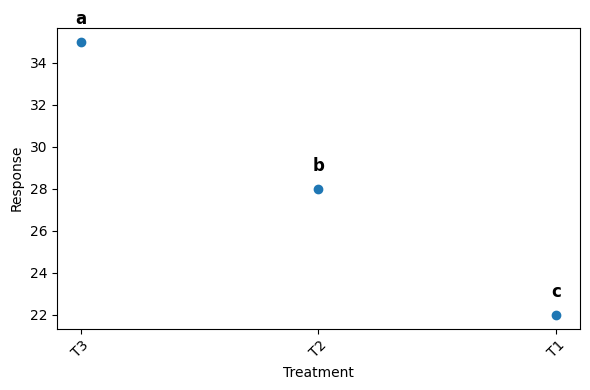


========== ASSUMPTIONS ==========
Shapiro p-value: {'Test': 'Shapiro-Wilk', 'Statistic': np.float64(0.8230370085706205), 'p-value': np.float64(0.03728747031154133), 'Normal': 'No'}

========== SUMMARY REPORT ==========


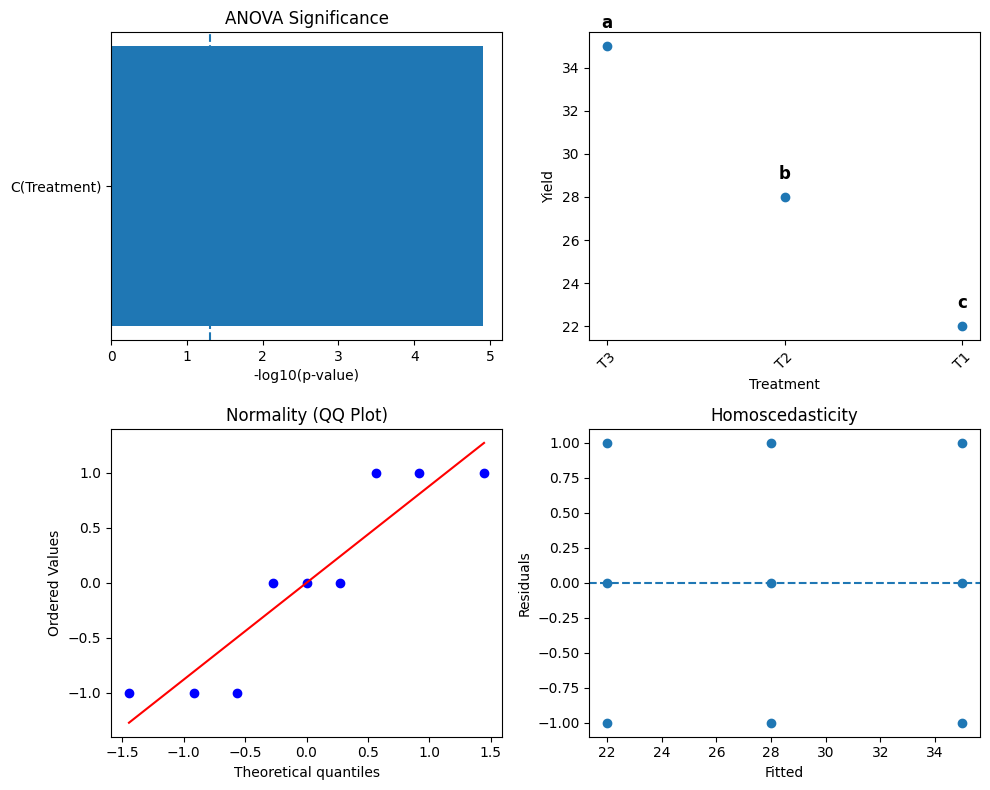

In [3]:
import pandas as pd
from agrodesign.experiment import Experiment

df = pd.DataFrame({
    "Treatment": ["T1","T1","T1","T2","T2","T2","T3","T3","T3"],
    "Yield": [22,21,23, 28,27,29, 35,34,36]
})

Experiment(df,"Yield").crd("Treatment").analyze()



========== AGRODESIGN AUTOMATIC ANALYSIS ==========

Design detected: RCBD

ANOVA TABLE
               DF          SS         MS      F   p-value
C(Treatment)  2.0  122.000000  61.000000  45.75  0.001754
C(Rep)        2.0    0.666667   0.333333   0.25  0.790123
Residual      4.0    5.333333   1.333333    NaN       NaN

========== MEAN COMPARISON ==========

Effect: Treatment
HSD(0.05) = 3.3554
  Treatment  Mean  Replications Group
0        T3  30.0             3     a
1        T2  25.0             3     b
2        T1  21.0             3     c


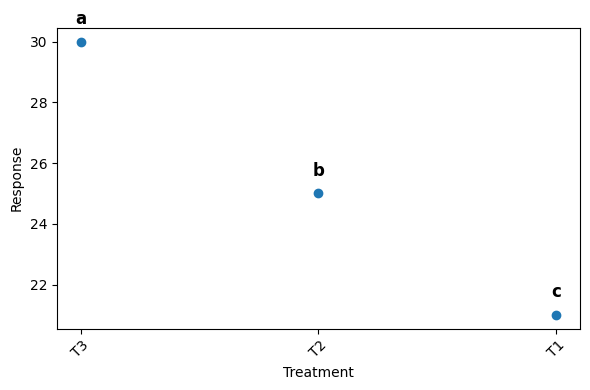


========== ASSUMPTIONS ==========
Shapiro p-value: {'Test': 'Shapiro-Wilk', 'Statistic': np.float64(0.9157185892182578), 'p-value': np.float64(0.35797348635126475), 'Normal': 'Yes'}

========== SUMMARY REPORT ==========


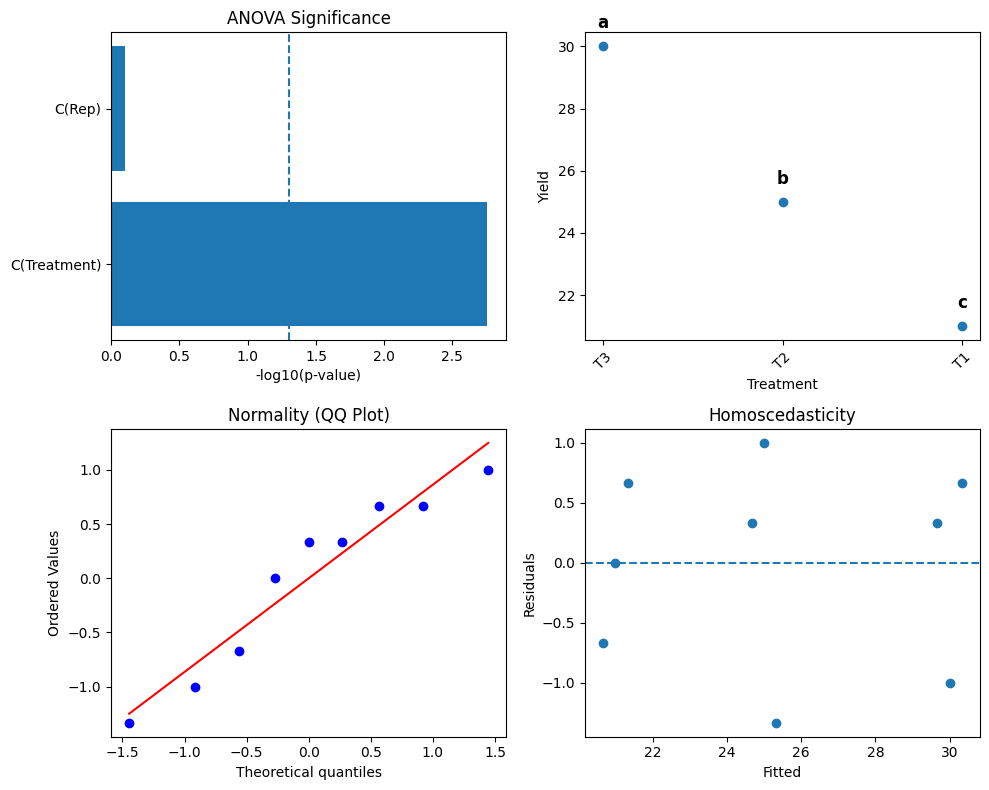

In [4]:
import pandas as pd
from agrodesign.experiment import Experiment

df = pd.DataFrame({
    "Rep": [1,1,1, 2,2,2, 3,3,3],
    "Treatment": ["T1","T2","T3"]*3,
    "Yield": [20,25,30, 21,26,29, 22,24,31]
})

Experiment(df,"Yield").rcbd("Treatment","Rep").analyze()



========== AGRODESIGN AUTOMATIC ANALYSIS ==========

Design detected: SPLIT

ANOVA TABLE
              DF            SS            MS             F       p-value
C(Rep)       1.0  1.262177e-29  1.262177e-29  5.797101e-02  8.321637e-01
C(A)         1.0  9.800000e+01  9.800000e+01  4.900000e+01  9.033447e-02
C(B)         1.0  8.000000e+00  8.000000e+00  3.674350e+28  2.721570e-29
C(Rep):C(A)  1.0  2.000000e+00  2.000000e+00  9.185874e+27  1.088628e-28
C(A):C(B)    1.0  3.155444e-30  3.155444e-30  1.449275e-02  9.151811e-01
Residual     2.0  4.354512e-28  2.177256e-28           NaN           NaN

========== MEAN COMPARISON ==========

Effect: A
HSD(0.05) = 0.0000
    A  Mean  Replications Group
0  A2  18.5             4     a
1  A1  11.5             4     b


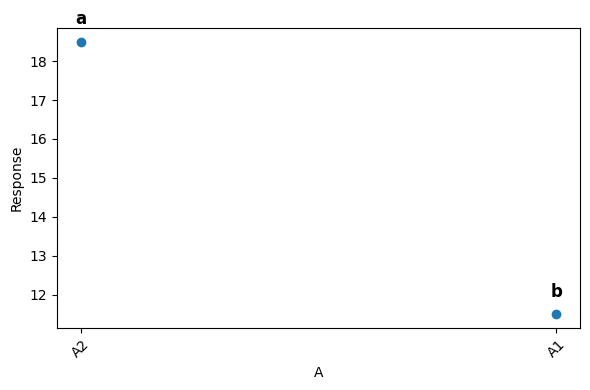


Effect: B
HSD(0.05) = 0.0000
    B  Mean  Replications Group
0  B2  16.0             4     a
1  B1  14.0             4     b


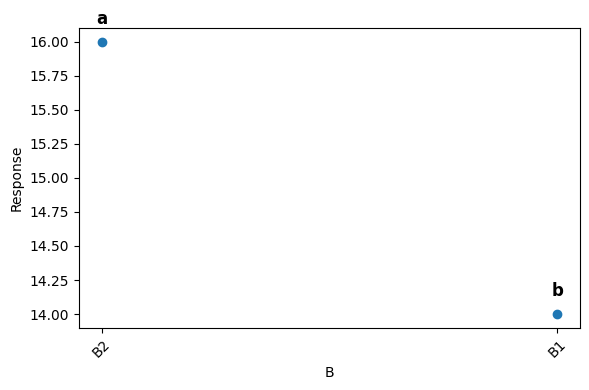


Effect: A × B
HSD(0.05) = 0.0000
    A   B  Mean  Replications Group
0  A2  B2  19.5             2     a
1  A2  B1  17.5             2     b
2  A1  B2  12.5             2     c
3  A1  B1  10.5             2     d


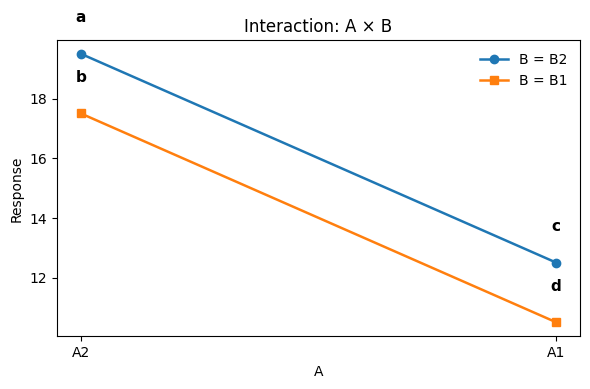


========== ASSUMPTIONS ==========
Shapiro p-value: {'Test': 'Shapiro-Wilk', 'Statistic': np.float64(0.9672994330151466), 'p-value': np.float64(0.876014664922366), 'Normal': 'Yes'}

========== SUMMARY REPORT ==========


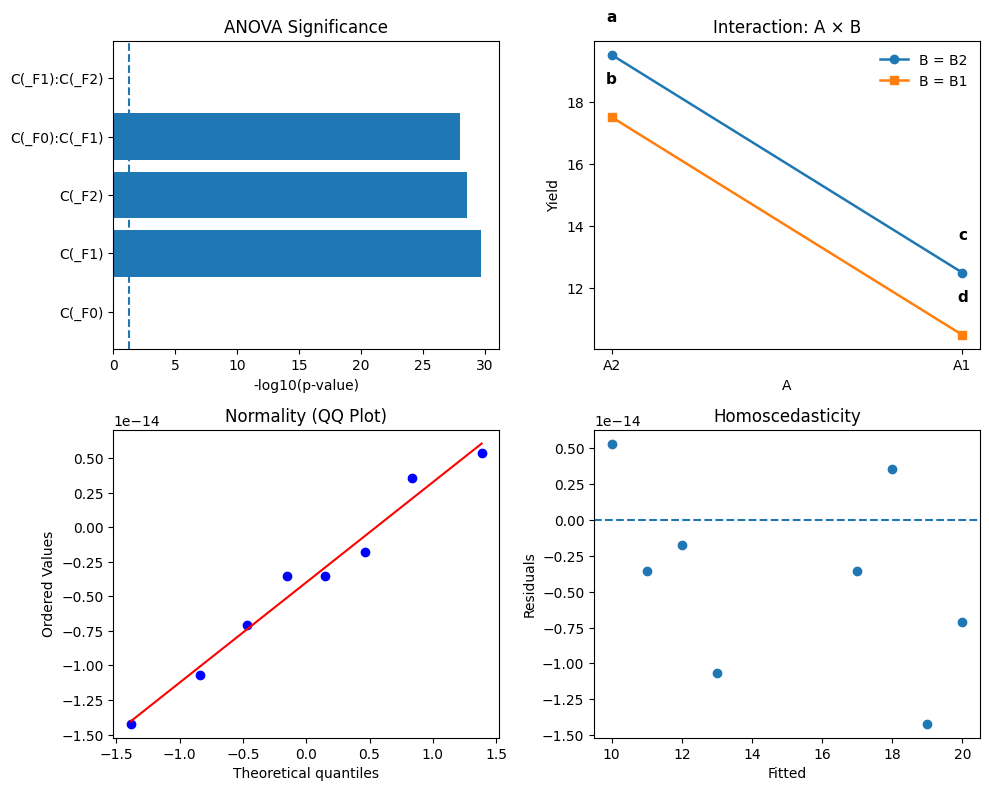

In [5]:
import pandas as pd
from agrodesign.experiment import Experiment

df = pd.DataFrame({
    "Rep":[1,1,1,1,2,2,2,2],
    "A":["A1","A1","A2","A2"]*2,
    "B":["B1","B2","B1","B2"]*2,
    "Yield":[10,12,18,20,11,13,17,19]
})

Experiment(df,"Yield").split_plot("A","B","Rep").analyze()


In [ ]:
import pandas as pd
from agrodesign.experiment import Experiment

df = pd.DataFrame({
    "Block":[1,1,1,1,2,2,2,2,3,3,3,3],
    "Treatment":["T1","T2","T3","T4"]*3,
    "Yield":[42,50,55,60, 40,48,54,59, 43,49,56,61]
})

Experiment(df,"Yield").mixed(fixed=["Treatment"], random=["Block"]).analyze()


========== AGRODESIGN AUTOMATIC ANALYSIS ==========

Mixed model analysis
     Effect            Type  Variance   Std.Dev
0     Block  Random (Group)  0.999998  0.999999
1  Residual           Error  0.333333  0.577350

BLUPs
   Block      BLUP
0      3  0.769231
1      1  0.307692
2      2 -1.076923


In [2]:
import pandas as pd
df = pd.DataFrame({
    "Genotype":["G1","G2","G3","G4"]*8,
    "Environment":(["E1"]*4 + ["E2"]*4 + ["E3"]*4 + ["E4"]*4)*2,
    "Rep":[1]*16 + [2]*16,
    "Yield":[
        42,50,55,60,
        44,52,57,63,
        40,48,54,58,
        41,49,56,59,

        43,51,56,61,
        45,53,58,64,
        41,47,55,57,
        42,50,57,60
    ]
})
Experiment(df,"Yield").gxe("Genotype","Environment","Rep").analyze()



========== AGRODESIGN AUTOMATIC ANALYSIS ==========

G×E analysis

ANOVA
                            sum_sq    df           F        PR(>F)
C(Genotype)                 1464.5   3.0  976.333333  2.527981e-18
C(Environment)                82.5   3.0   55.000000  1.194823e-08
C(Genotype):C(Environment)     8.5   9.0    1.888889  1.279687e-01
Residual                       8.0  16.0         NaN           NaN

Variance Components
  Variance Component      Value
0           Genotype  60.936667
1           Residual   0.660002

Heritability: 0.9946136929964106

Genotype BLUPs
  Genotype      BLUP
0       G4  8.114015
1       G3  3.869761
2       G2 -2.122127
3       G1 -9.861649


D:\Git Projects\AGRODESIGN\agrodesign\mixed\gxe.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  val = float(values[0])


In [4]:
aov = Anova(df, response="Yield")
anova_table = aov.split_plot(
    whole_plot="A",
    sub_plot="B",
    block="Rep"
)

anova_table


,DF,SS,MS,F,p-value
C(Rep),1.0,50.000000,50.000000,25.000000,0.007490
C(A),1.0,0.333333,0.333333,0.453678,0.622639
C(B),1.0,3.266667,3.266667,1.633333,0.270369
C(Rep):C(A),1.0,0.734735,0.734735,0.367368,0.577155
C(A):C(B),1.0,1.665265,1.665265,0.832632,0.413134
Residual,4.0,8.000000,2.000000,NaN,NaN


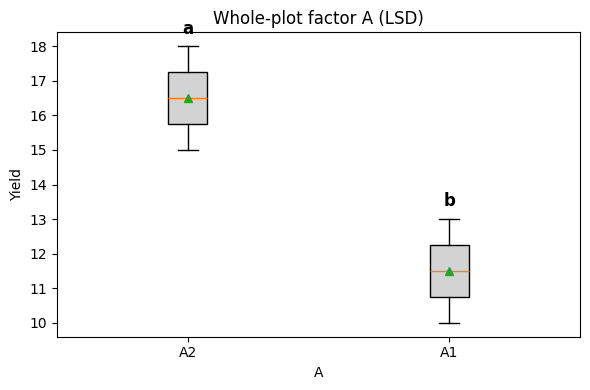

In [5]:
boxplot_letters(
    aov,
    factor="A",
    method="lsd",
    ylabel="Yield",
    title="Whole-plot factor A (LSD)"
)


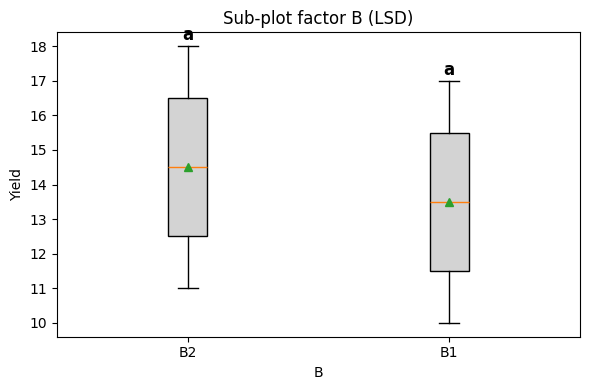

In [6]:
boxplot_letters(
    aov,
    factor="B",
    method="lsd",
    ylabel="Yield",
    title="Sub-plot factor B (LSD)"
)


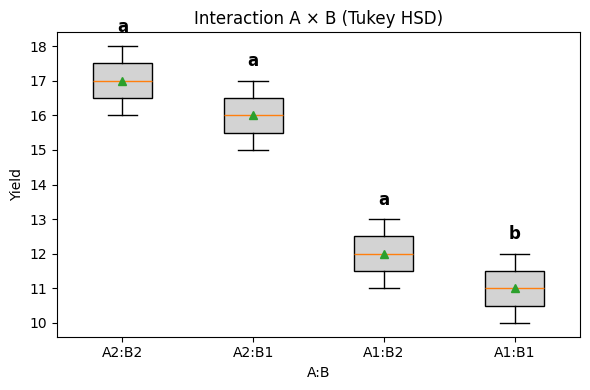

In [7]:
boxplot_letters(
    aov,
    factor=["A","B"],
    method="tukey",
    ylabel="Yield",
    title="Interaction A × B (Tukey HSD)"
)


In [1]:
from importlib import reload
import agrodesign.mixed.lmm as lmm
reload(lmm)

<module 'agrodesign.mixed.lmm' from 'D:\\Git Projects\\AGRODESIGN\\agrodesign\\mixed\\lmm.py'>

In [2]:
import pandas as pd

df = pd.DataFrame({
    "Block": [1,1,1,1, 2,2,2,2, 3,3,3,3, 4,4,4,4],
    "Treatment": [
        "T1","T2","T3","T4",
        "T1","T2","T3","T4",
        "T1","T2","T3","T4",
        "T1","T2","T3","T4"
    ],
    "Yield": [
        42, 50, 55, 60,
        40, 48, 54, 59,
        43, 49, 56, 61,
        41, 47, 53, 58
    ]
})

df


,Block,Treatment,Yield
0,1,T1,42
1,1,T2,50
2,1,T3,55
3,1,T4,60
4,2,T1,40
5,2,T2,48
6,2,T3,54
7,2,T4,59
8,3,T1,43
9,3,T2,49


In [3]:
from agrodesign.mixed import MixedModel
model = MixedModel(df, response="Yield")

model.fit(
    fixed=["Treatment"],
    random=["Block"]
)

model.summary()


,Effect,Type,Variance,Std.Dev
0,Block,Random (Group),1.333322,1.154696
1,Residual,Error,0.333334,0.577351


In [5]:
from agrodesign.mixed import MixedModel

model = MixedModel(df, response="Yield")

model.fit(
    fixed=["Treatment"],
    random=["Block"]
)

model.blup("Block")


D:\Git Projects\AGRODESIGN\agrodesign\mixed\lmm.py:159: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  values.append([level, float(val)])


,Block,BLUP
0,3,1.176470
1,1,0.705882
2,2,-0.705882
3,4,-1.176470


In [6]:
model.heritability("Treatment","Block")

0.9411758807096782

In [7]:
import pandas as pd

df = pd.DataFrame({
    "Location": ["L1"]*6 + ["L2"]*6,
    "Block":    [1,1,1,2,2,2]*2,
    "Genotype": ["G1","G2","G3"]*4,
    "Yield":    [42,51,48,44,53,50,38,47,46,41,49,47]
})


In [11]:
from agrodesign.mixed import MixedModel

model = MixedModel(df, response="Yield")

model.fit(
    fixed=["Genotype"],
    random=["Block"]
)

print(model.summary())
print(model.blup("Block"))
print(model.heritability("Genotype","Block"))


     Effect            Type  Variance   Std.Dev
0     Block  Random (Group)  1.260448  1.122697
1  Residual           Error  4.437492  2.106535
   Block      BLUP
0      2  0.630215
1      1 -0.630215
0.36228163347164744


D:\Git Projects\AGRODESIGN\agrodesign\mixed\lmm.py:159: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  values.append([level, float(val)])


In [1]:
import pandas as pd

In [2]:
df = pd.DataFrame({
"Env": ["E1"]*12 + ["E2"]*12,
"Block": [1,1,1,2,2,2]*4,
"Genotype": ["G1","G2","G3"]*8,
"Yield": [
42,51,48,44,53,50,43,52,49,45,54,51,
38,47,46,41,49,47,39,48,47,42,50,48
]})
df

,Env,Block,Genotype,Yield
0,E1,1,G1,42
1,E1,1,G2,51
2,E1,1,G3,48
3,E1,2,G1,44
4,E1,2,G2,53
5,E1,2,G3,50
6,E1,1,G1,43
7,E1,1,G2,52
8,E1,1,G3,49
9,E1,2,G1,45


In [3]:
from agrodesign.mixed.gxe import GxEModel

gxe = GxEModel(df, response="Yield")

gxe.fit(
    genotype="Genotype",
    environment="Env",
    block="Block"
)

gxe.summary()


d:\Git Projects\AGRODESIGN\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
d:\Git Projects\AGRODESIGN\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
d:\Git Projects\AGRODESIGN\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
d:\Git Projects\AGRODESIGN\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
d:\Git Projects\AGRODESIGN\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  war

,Component,Variance
0,Block(Environment),0.000927
1,Genotype,8.850933
2,GxE,8.850933
3,Residual,0.499571


In [4]:
gxe.heritability()

np.float64(0.6604536970571756)

In [5]:
gxe.stability()

np.float64(8.850932536442736)

In [1]:
import pandas as pd
df = pd.DataFrame({
"Env": ["E1"]*12 + ["E2"]*12 + ["E3"]*12,
"Genotype": ["G1","G2","G3","G4"]*9,
"Yield": [
42,50,55,60, 44,52,57,63, 41,49,54,59,
38,46,52,58, 40,48,54,60, 37,45,51,56,
45,53,59,64, 46,55,61,66, 44,52,58,63
]})


In [2]:
from agrodesign.mixed.ammi import AMMI

ammi = AMMI(df, genotype="Genotype", environment="Env", response="Yield")

ammi.fit()


In [3]:
print(ammi.anova())

        Source  DF          SS          MS          F       p-value
0     Genotype   3  601.805556  200.601852  79.358974  1.341149e-12
1  Environment   2   91.129630   45.564815  18.025641  1.660609e-05
2          G×E   6    0.944444    0.157407   0.062271  9.988449e-01
3        IPCA1   4    0.803621    0.200905   0.079479  9.878862e-01
4        IPCA2   2    0.140824    0.070412   0.027855  9.725606e-01


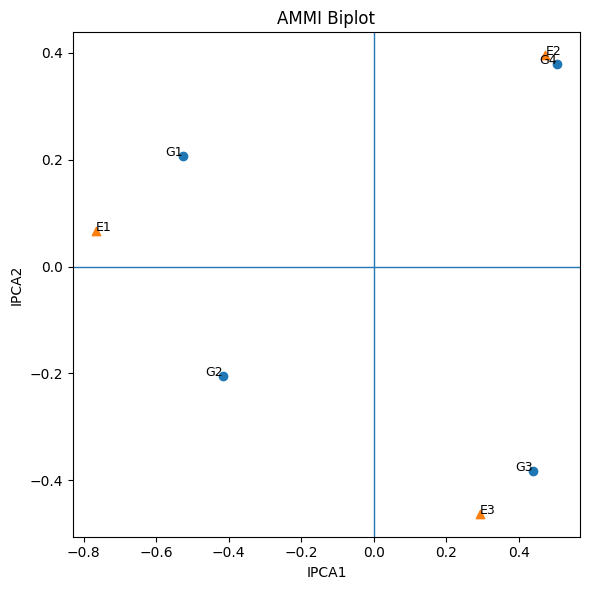

In [6]:
from agrodesign.mixed.ammi import AMMI
from agrodesign.plots.ammi_biplot import ammi_biplot

ammi = AMMI(df, genotype="Genotype", environment="Env", response="Yield")
ammi.fit()

ammi_biplot(ammi)


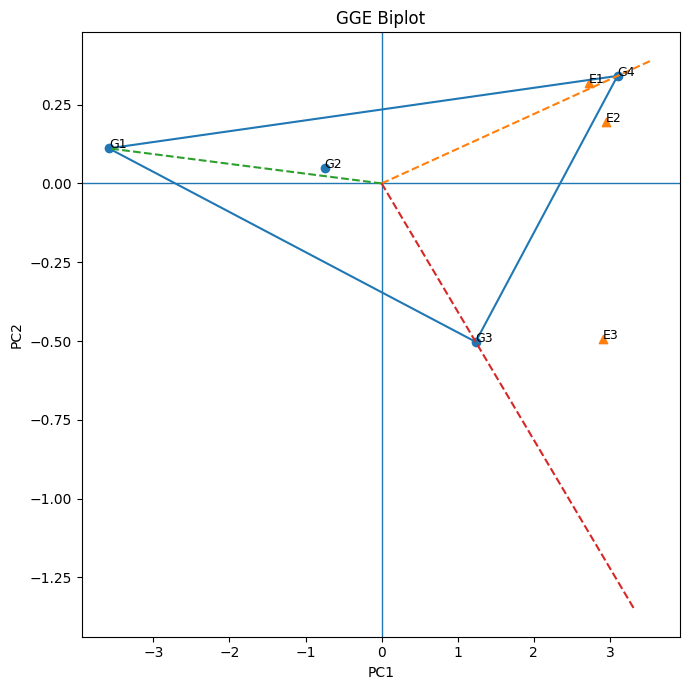

In [7]:
from agrodesign.plots.gge_biplot import gge_biplot

gge_biplot(df, genotype="Genotype", environment="Env", response="Yield")


In [3]:
from agrodesign.mixed.finlay_wilkinson import FinlayWilkinson

fw = FinlayWilkinson(df,
                     genotype="Genotype",
                     environment="Env",
                     response="Yield")

fw.fit()

,Genotype,MeanYield,Bi,S2di,R2
0,G1,41.888889,0.988417,0.260832,0.988417
1,G2,50.000000,1.037594,0.139098,0.994361
2,G3,55.666667,1.036375,0.196708,0.992025
3,G4,61.000000,0.937614,0.193739,0.990420


In [4]:
fw.classify()

,Genotype,MeanYield,Bi,S2di,R2,Adaptation
3,G4,61.000000,0.937614,0.193739,0.990420,Widely adapted
2,G3,55.666667,1.036375,0.196708,0.992025,Widely adapted
1,G2,50.000000,1.037594,0.139098,0.994361,Widely adapted
0,G1,41.888889,0.988417,0.260832,0.988417,Widely adapted


In [2]:
from agrodesign.mixed.eberhart_russell import EberhartRussell

er = EberhartRussell(df,
                     genotype="Genotype",
                     environment="Env",
                     response="Yield")

er.fit()

,Genotype,MeanYield,bi,S2di,t(bi=1),p(bi=1),R2
0,G1,41.888889,0.988417,0.260832,-0.108253,0.931351,0.988417
1,G2,50.000000,1.037594,0.139098,0.481125,0.714518,0.994361
2,G3,55.666667,1.036375,0.196708,0.391461,0.762462,0.992025
3,G4,61.000000,0.937614,0.193739,-0.676513,0.621346,0.990420


In [3]:
er.classify()

,Genotype,MeanYield,bi,S2di,t(bi=1),p(bi=1),R2,Adaptation
3,G4,61.000000,0.937614,0.193739,-0.676513,0.621346,0.990420,Widely adapted (stable)
2,G3,55.666667,1.036375,0.196708,0.391461,0.762462,0.992025,Unstable
1,G2,50.000000,1.037594,0.139098,0.481125,0.714518,0.994361,Widely adapted (stable)
0,G1,41.888889,0.988417,0.260832,-0.108253,0.931351,0.988417,Unstable


In [2]:
from agrodesign.mixed.ammi import AMMI
from agrodesign.mixed.finlay_wilkinson import FinlayWilkinson
from agrodesign.mixed.eberhart_russell import EberhartRussell
from agrodesign.mixed.stability_report import StabilityReport

ammi = AMMI(df,"Genotype","Env","Yield").fit()
fw = FinlayWilkinson(df,"Genotype","Env","Yield")
er = EberhartRussell(df,"Genotype","Env","Yield")

report = StabilityReport(ammi,fw,er)


In [3]:
report

In [4]:
report.build()

,MeanYield,ASV,Bi,S2di,R2,bi,t(bi=1),p(bi=1),Recommendation
Genotype,,,,,,,,,
G4,61.000000,1.263950,0.937614,0.193739,0.990420,0.937614,-0.676513,0.621346,Specific adaptation
G3,55.666667,1.113752,1.036375,0.196708,0.992025,1.036375,0.391461,0.762462,Specific adaptation
G2,50.000000,1.016209,1.037594,0.139098,0.994361,1.037594,0.481125,0.714518,Ideal genotype (widely adapted)
G1,41.888889,1.272883,0.988417,0.260832,0.988417,0.988417,-0.108253,0.931351,Specific adaptation


In [5]:
report.best()

MeanYield                        61.0
ASV                           1.26395
Bi                           0.937614
S2di                         0.193739
R2                            0.99042
bi                           0.937614
t(bi=1)                     -0.676513
p(bi=1)                      0.621346
Recommendation    Specific adaptation
Name: G4, dtype: object

In [4]:
print(ammi.stability())

         Genotype       ASV
Genotype                   
G2             G2  1.016209
G3             G3  1.113752
G4             G4  1.263950
G1             G1  1.272883


In [5]:
print(ammi.ranking())

          MeanYield  Stability  Rank
Genotype                            
G2        50.000000   1.016209   4.0
G3        55.666667   1.113752   4.0
G4        61.000000   1.263950   4.0
G1        41.888889   1.272883   8.0
